# Explainability in Logistic Regression (Customer Churn Fake Dataset)

In [ ]:
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(n_samples=1000, n_features=5, n_informative=5, n_redundant=0, n_classes=2, random_state=42)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5'])

df['churn'] = y

print("First 5 rows of the generated DataFrame:")
print(df.head())

print("\nDistribution of the 'churn' column:")
print(df['churn'].value_counts())

First 5 rows of the generated DataFrame:
   feature_1  feature_2  feature_3  feature_4  feature_5  churn
0   0.751790   3.184258   0.092019   1.227394  -0.997310      1
1   0.807304   1.126680   2.787603   1.988043  -0.331954      1
2   1.563154  -0.495054   1.727100   1.308530  -0.413501      1
3   3.002685  -0.547441  -0.087456   2.586871   0.608524      0
4  -0.684031  -0.556652   2.439790  -1.862443   2.160116      1

Distribution of the 'churn' column:
churn
1    500
0    500
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

X = df.drop('churn', axis=1)
y = df['churn']

model = LogisticRegression(solver='liblinear', random_state=42)

model.fit(X, y)

print("Logistic Regression Model trained successfully!")

print("\nModel Coefficients:")
for i, col in enumerate(X.columns):
    print(f"{col}: {model.coef_[0][i]:.4f}")
print(f"Intercept: {model.intercept_[0]:.4f}")

Logistic Regression Model trained successfully!

Model Coefficients:
feature_1: -0.7461
feature_2: 0.8422
feature_3: 0.6936
feature_4: -0.3051
feature_5: -0.7187
Intercept: 0.7327


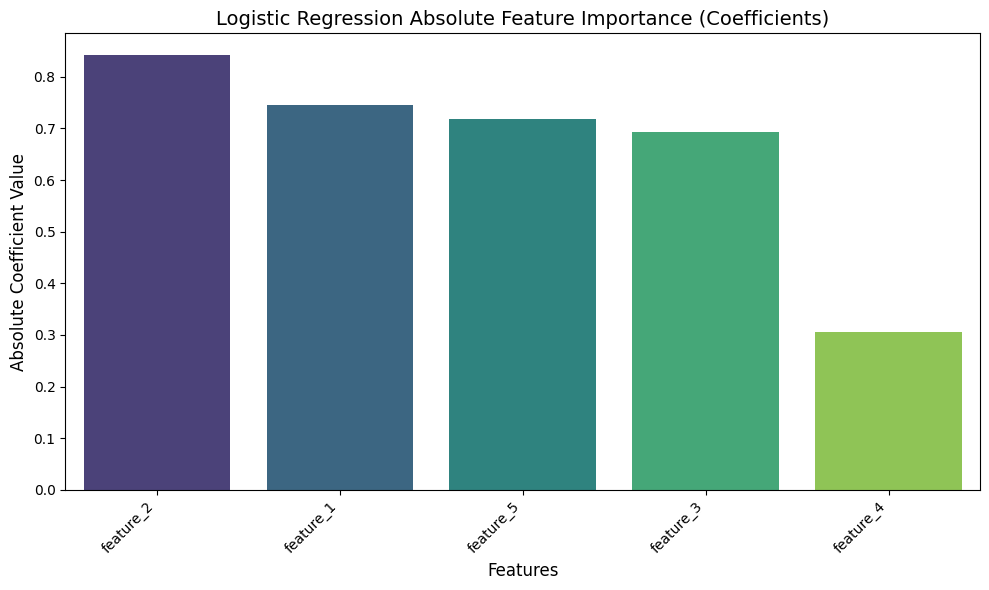

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

coefficients = pd.Series(model.coef_[0], index=X.columns)

coefficients_sorted = coefficients.abs().sort_values(ascending=False).index
coefficients = coefficients[coefficients_sorted]

plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.index, y=coefficients.abs().values,
            hue=coefficients.index,
            palette='viridis',
            legend=False)

plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute Coefficient Value', fontsize=12)

plt.title('Logistic Regression Absolute Feature Importance (Coefficients)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Explainability in SVM (Iris Dataset -> Binary)

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

In [ ]:
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target

df_binary = df_iris[df_iris['species'].isin([0, 1])]

X = df_binary[['sepal length (cm)', 'petal length (cm)']]
y = df_binary['species']

print("Binary Iris dataset prepared successfully.")
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 rows of y:")
print(y.head())

Binary Iris dataset prepared successfully.

First 5 rows of X:
   sepal length (cm)  petal length (cm)
0                5.1                1.4
1                4.9                1.4
2                4.7                1.3
3                4.6                1.5
4                5.0                1.4

First 5 rows of y:
0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X, y)

SVC(kernel='linear', random_state=42)

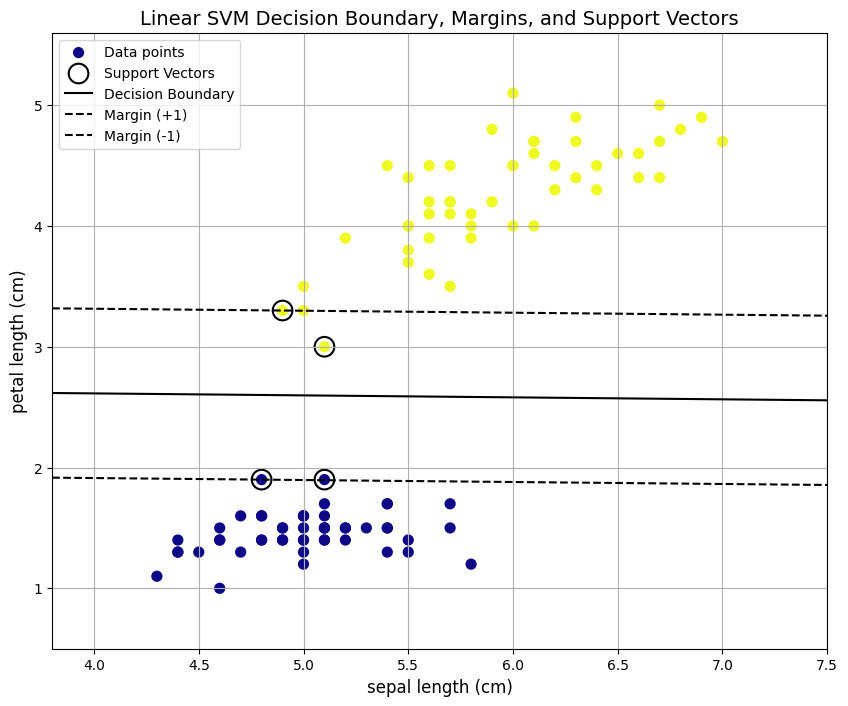

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='plasma', s=50, label='Data points')
plt.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='k', label='Support Vectors', linewidth=1.5)

w = svm_model.coef_[0]
b = svm_model.intercept_[0]

x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
x_values = np.linspace(x_min, x_max, 100)

y_decision_boundary = (-w[0] * x_values - b) / w[1]

y_margin_plus = (-w[0] * x_values - b + 1) / w[1]

y_margin_minus = (-w[0] * x_values - b - 1) / w[1]

plt.plot(x_values, y_decision_boundary, 'k-', label='Decision Boundary')
plt.plot(x_values, y_margin_plus, 'k--', label='Margin (+1)')
plt.plot(x_values, y_margin_minus, 'k--', label='Margin (-1)')

plt.legend(loc='best')

plt.xlabel(X.columns[0], fontsize=12)
plt.ylabel(X.columns[1], fontsize=12)

plt.title('Linear SVM Decision Boundary, Margins, and Support Vectors', fontsize=14)

plt.xlim(x_min, x_max)
plt.ylim(X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5)

plt.grid(True)

plt.show()
